### 1. Bibliotecas

In [49]:
import pandas as pd
import numpy as np

import warnings
import os

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler #OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error

import xgboost as xgb

In [ ]:
# Definindo diretório
os.chdir("")

# Exibir todas as linhas e colunas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# Ignorar avisos
warnings.filterwarnings("ignore")

### 2. Explorando os dados

In [51]:
# Importando os dados
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv('sample_submission.csv')

In [52]:
# Primeiras observações
train.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [53]:
# Informação sobre o df
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [54]:
# Número de observações faltantes
train.isna().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

#### 2.1 Número de observações por podcast

Há 48 podcasts em um conjunto de dados com 750.000 observações. Isso representa um grande número de observações para uma quantidade relativamente pequena de podcasts. Portanto, ao tratar os dados faltantes posteriormente, será possível realizar esse tratamento de forma específica para cada podcast.

In [55]:
# Número de nome de podcasts
num_podcasts = train['Podcast_Name'].nunique()
print(f"🎙️ Total de podcasts únicos: {num_podcasts}")

# Contagem de observações por nome de podcast
top_podcasts = train['Podcast_Name'].value_counts().head()

print("\n📈 Top 5 podcasts com mais episódios:")
for name, count in top_podcasts.items():
    print(f"• {name}: {count} episódios")

🎙️ Total de podcasts únicos: 48

📈 Top 5 podcasts com mais episódios:
• Tech Talks: 22847 episódios
• Sports Weekly: 20053 episódios
• Funny Folks: 19635 episódios
• Tech Trends: 19549 episódios
• Fitness First: 19488 episódios


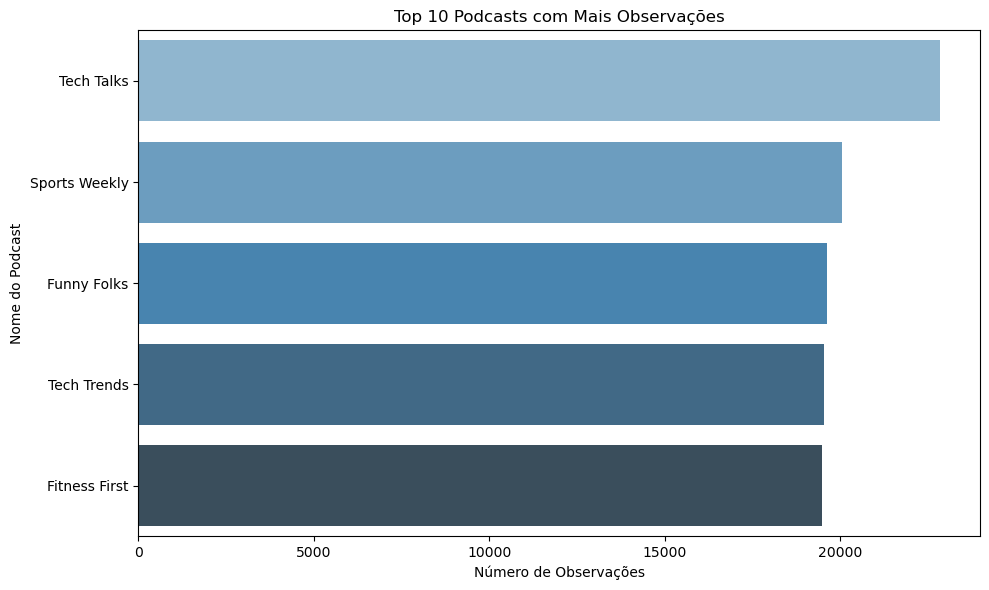

In [56]:
# Top 10 podcasts com mais observações
top_podcasts = train['Podcast_Name'].value_counts().head()

plt.figure(figsize=(10, 6))
sns.barplot(x=top_podcasts.values, y=top_podcasts.index, palette='Blues_d')
plt.xlabel('Número de Observações')
plt.ylabel('Nome do Podcast')
plt.title('Top 10 Podcasts com Mais Observações')
plt.tight_layout()
plt.show()

#### 2.2 Estatísticas descritivas - variáveis numéricas

In [57]:
# Estatísticas descritivas
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,750000.0,374999.500000,216506.495284,0.0,187499.75000,374999.50000,562499.25000,749999.00
Episode_Length_minutes,662907.0,64.504738,32.969603,0.0,35.73000,63.84000,94.07000,325.24
Host_Popularity_percentage,750000.0,59.859901,22.873098,1.3,39.41000,60.05000,79.53000,119.46
Guest_Popularity_percentage,603970.0,52.236449,28.451241,0.0,28.38000,53.58000,76.60000,119.91
Number_of_Ads,749999.0,1.348855,1.151130,0.0,0.00000,1.00000,2.00000,103.91
Listening_Time_minutes,750000.0,45.437406,27.138306,0.0,23.17835,43.37946,64.81158,119.97


##### Episode_Length_minutes

Ao analisar o atributo Episode_Length_minutes, observa-se que a maioria dos episódios possui duração de até 125 minutos. No entanto, há uma exceção: um episódio com duração de 325,24 minutos, valor significativamente superior aos demais. Esse caso pode ser considerado um outlier ou possivelmente um erro de digitação. No conjunto de teste, apenas dois episódios ultrapassaram os 125 minutos de duração.

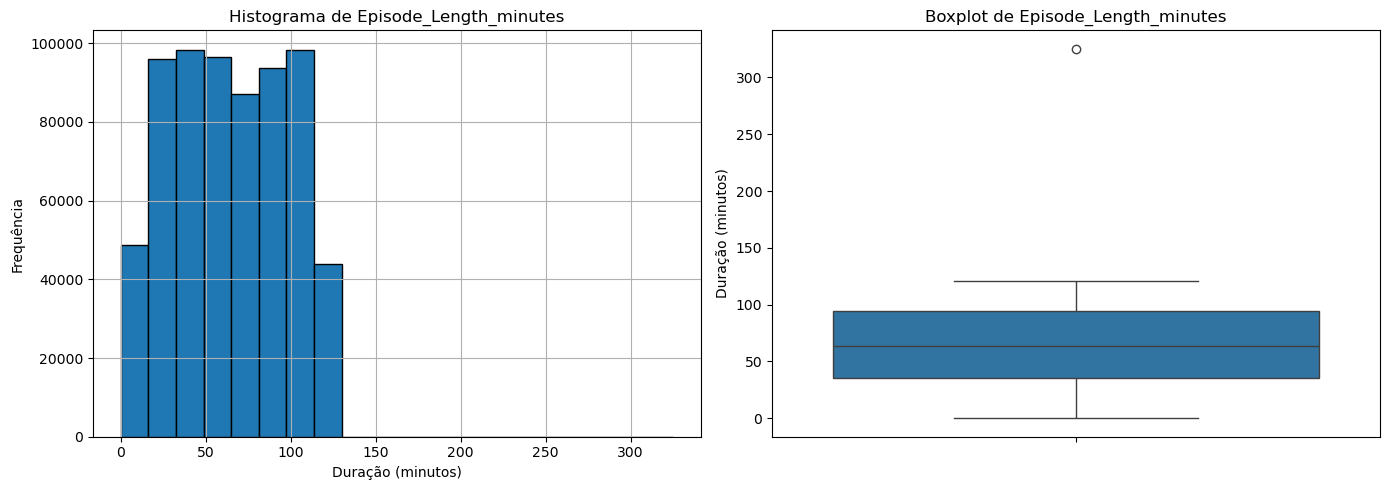

In [58]:
# Cria uma figura com 1 linha e 2 colunas de subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Histograma no primeiro subplot
axes[0].hist(train['Episode_Length_minutes'], bins=20, edgecolor='black')
axes[0].set_title('Histograma de Episode_Length_minutes')
axes[0].set_xlabel('Duração (minutos)')
axes[0].set_ylabel('Frequência')
axes[0].grid(True)

# Boxplot no segundo subplot
sns.boxplot(y=train['Episode_Length_minutes'], ax=axes[1])
axes[1].set_title('Boxplot de Episode_Length_minutes')
axes[1].set_ylabel('Duração (minutos)')

# Ajusta o layout para evitar sobreposição
plt.tight_layout()
plt.show()

In [59]:
# Definindo os intervalos (bins) e os rótulos
bins = [0, 25, 50, 75, 100, 125, np.inf]
labels = ['1–25', '26–50', '51–75', '76–100', '101–125', '125+']

# Criando a tabela diretamente, sem adicionar coluna ao DataFrame
tabela = pd.cut(train['Episode_Length_minutes'], bins=bins, labels=labels, right=True)\
           .value_counts().sort_index().reset_index()
tabela.columns = ['Intervalo', 'Número de Observações']

print(tabela)

  Intervalo  Número de Observações
0      1–25                  93724
1     26–50                 156995
2     51–75                 143508
3    76–100                 141483
4   101–125                 127195
5      125+                      1


##### Host_Popularity_percentage e Guest_Popularity_percentage

Por alguma razão, há anfitriões e convidados que possuem mais que 100% de popularidade. Isto acontece tanto no conjunto de treino quanto no conjunto de teste.

In [60]:
# Host_Popularity_percentage

# Definindo os intervalos (bins) e os rótulos
bins = [0, 25, 50, 75, 100, np.inf]
labels = ['1–25', '26–50', '51–75', '76–100', '100+']

# Gerando a tabela diretamente com pd.cut() sem alterar o DataFrame original
tabela = pd.cut(train['Host_Popularity_percentage'], bins=bins, labels=labels, right=True)\
           .value_counts().sort_index().reset_index()

# Renomeando as colunas da tabela
tabela.columns = ['Intervalo', 'Número de Observações']

print(tabela)

  Intervalo  Número de Observações
0      1–25                  38796
1     26–50                 244601
2     51–75                 234713
3    76–100                 231865
4      100+                     25


In [61]:
# Host_Popularity_percentage

# Definindo os intervalos (bins) e os rótulos
bins = [0, 25, 50, 75, 100, np.inf]
labels = ['1–25', '26–50', '51–75', '76–100', '100+']

# Criando a tabela diretamente, sem criar nova coluna no DataFrame
tabela = pd.cut(train['Guest_Popularity_percentage'], bins=bins, labels=labels, right=True).value_counts().sort_index().reset_index()
tabela.columns = ['Intervalo', 'Número de Observações']

print(tabela)

  Intervalo  Número de Observações
0      1–25                 134231
1     26–50                 143365
2     51–75                 166140
3    76–100                 160212
4      100+                     19


##### Number_of_Ads

In [62]:
bins = [0, 1, 3, 4, 10, np.inf]
labels = ['0', '1–2', '3', '4–9', '10+']

tabela = pd.cut(train['Number_of_Ads'], bins=bins, labels=labels, right=False)\
           .value_counts().sort_index().reset_index()
tabela.columns = ['Intervalo', 'Número de Observações']
print(tabela)

  Intervalo  Número de Observações
0         0                 217592
1       1–2                 372225
2         3                 160173
3       4–9                      0
4       10+                      9


Em 5 epsódios, por exemplo, ocorreram 103 propagandas (dados de treino), esses valores também estão fracionados o que pode indicar um erro de digitação.

In [63]:
train["Number_of_Ads"].value_counts().sort_index(ascending=False)

Number_of_Ads
103.91         1
103.88         1
103.75         1
103.25         2
103.00         1
53.42          1
53.37          1
12.00          1
3.00      160173
2.00      158156
1.00      214069
0.00      217592
Name: count, dtype: int64

##### Listening_Time_minutes

Listening_Time_minutes é o atributo alvo, abaixo verificaremos quais dos outros atributos numéricos mais se correlacionam com tal variável. Episode_Length_minutes é o atributo com a maior correlação positiva e Number_of_Ads com a maior correlação negativa.

In [64]:
# Seleciona variáveis numéricas e remove a variável 'ID'
num_vars = train.select_dtypes(include='number').drop(columns=['id'])

# Calcula correlação com a variável alvo
correlacoes = num_vars.corr()['Listening_Time_minutes'].drop('Listening_Time_minutes')

# Ordena em ordem decrescente
correlacoes_ordenadas = correlacoes.sort_values(ascending=False)

# Exibe resultado
print(correlacoes_ordenadas)

Episode_Length_minutes         0.916749
Host_Popularity_percentage     0.050870
Guest_Popularity_percentage   -0.016014
Number_of_Ads                 -0.118337
Name: Listening_Time_minutes, dtype: float64


#### 2.3 Variáveis categóricas

##### Episode_Title

Episode_Title exibe qual a edição do podcast referente a Podcast_Name, podemos criar um novo atributo, episódios mais recentes podem indicar que aquele podcast já está consolidado.

In [65]:
# Número de valores diferentes em Episode_Title
train['Episode_Title'].nunique()

100

##### Genre

In [66]:
# Verificando quantos tipos de gênero existem
train['Genre'].nunique()

10

Verificando se estatísticamente os gêneros possuem um média de Listening_Time_minutes diferente uma das outras. Com um p-valor menor que 0,05 temos evidências que ao menos um gênero possuem um média diferente indicando que podemos criar dummies a partir dela.

In [67]:
# Agrupar os dados por gênero e extrair os minutos escutados
grupos = [grupo["Listening_Time_minutes"].values for nome, grupo in train.groupby("Genre")]

# Rodar o teste ANOVA
stat, p_value = f_oneway(*grupos)

print(f"Estatística F: {stat:.4f}")
print(f"Valor-p: {p_value:.4f}")

Estatística F: 45.4823
Valor-p: 0.0000


##### Publication_Day

Não há uma diferenção tão grande, os primeiros dias da semana, no entanto, apresentam uma maior quantidade média de minutos escutados.

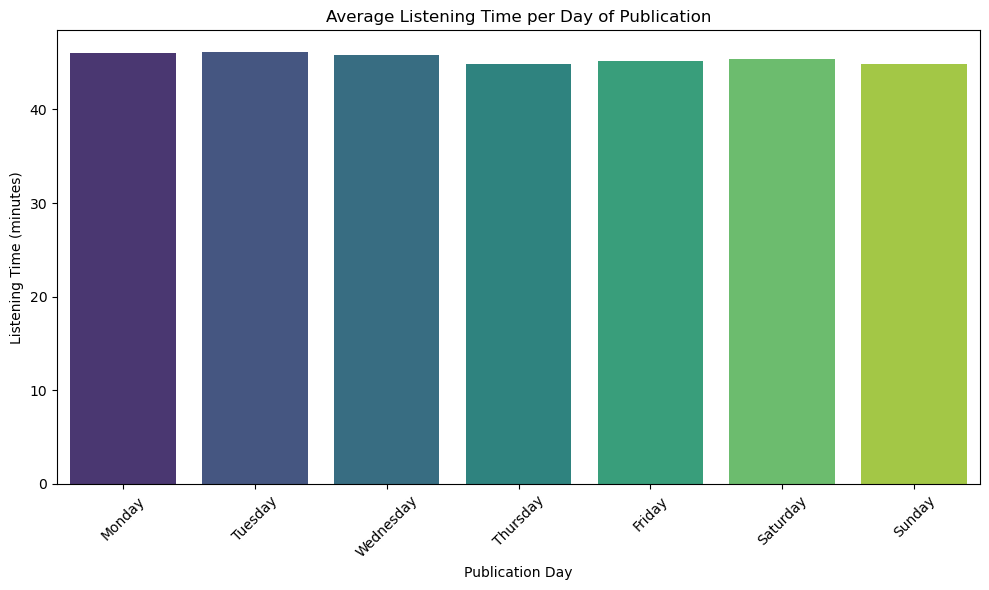

In [68]:
# Primeiro, define a ordem correta dos dias da semana
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Converte a coluna Publication_Day para categoria ordenada
train['Publication_Day'] = pd.Categorical(train['Publication_Day'], categories=ordem_dias, ordered=True)

# Agrupa e calcula a média
media_por_dia = train.groupby('Publication_Day')['Listening_Time_minutes'].mean().reset_index()

# Plota o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=media_por_dia, x='Publication_Day', y='Listening_Time_minutes', palette='viridis')
plt.title('Average Listening Time per Day of Publication')
plt.xlabel('Publication Day')
plt.ylabel('Listening Time (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Publication_Time

O mesmo acontece para Publication_Time, episódios publicados à noite aparentam tem uma média maior de atenção.

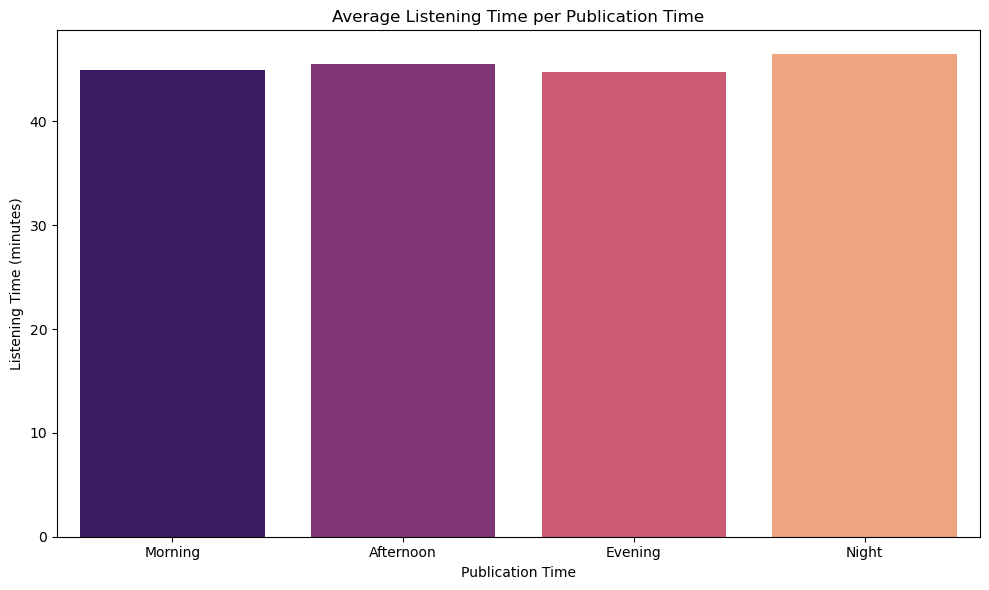

In [69]:
# Define a ordem correta dos períodos do dia
ordem_periodos = ['Morning', 'Afternoon', 'Evening', 'Night']

# Converte a coluna Publication_Time para categoria ordenada
train['Publication_Time'] = pd.Categorical(train['Publication_Time'], categories=ordem_periodos, ordered=True)

# Agrupa e calcula a média de Listening_Time_minutes por Publication_Time
media_por_periodo = train.groupby('Publication_Time')['Listening_Time_minutes'].mean().reset_index()

# Plota o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=media_por_periodo, x='Publication_Time', y='Listening_Time_minutes', palette='magma')
plt.title('Average Listening Time per Publication Time')
plt.xlabel('Publication Time')
plt.ylabel('Listening Time (minutes)')
plt.tight_layout()
plt.show()

##### Episode_Sentiment

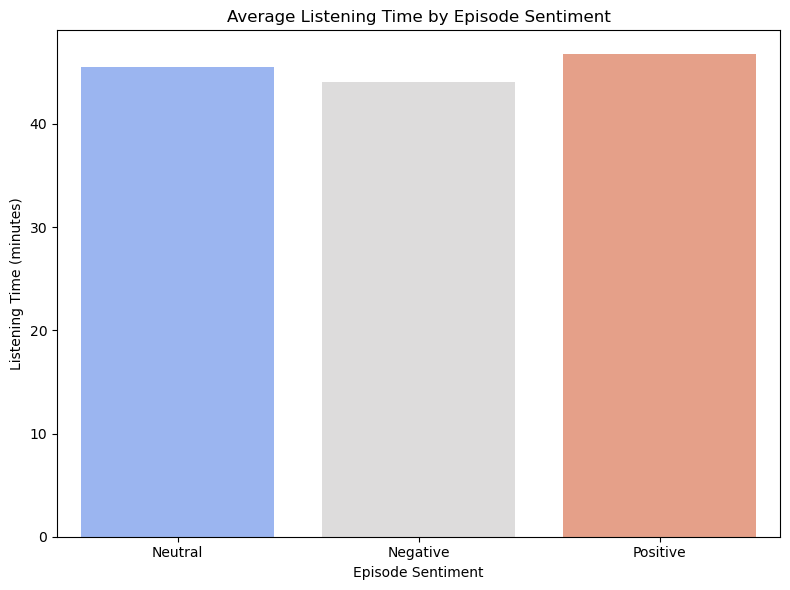

In [70]:
# Define a ordem desejada dos sentimentos
ordem_sentimentos = ['Neutral', 'Negative', 'Positive']

# Converte Episode_Sentiment para categoria ordenada
train['Episode_Sentiment'] = pd.Categorical(train['Episode_Sentiment'], categories=ordem_sentimentos, ordered=True)

# Agrupa e calcula a média
media_por_sentimento = train.groupby('Episode_Sentiment')['Listening_Time_minutes'].mean().reset_index()

# Plota o gráfico
plt.figure(figsize=(8, 6))
sns.barplot(data=media_por_sentimento, x='Episode_Sentiment', y='Listening_Time_minutes', palette='coolwarm')
plt.title('Average Listening Time by Episode Sentiment')
plt.xlabel('Episode Sentiment')
plt.ylabel('Listening Time (minutes)')
plt.tight_layout()
plt.show()

### 3. Separando em treino e validação

In [71]:
target = "Listening_Time_minutes"
X = train.drop(columns=[target])
y = train[target]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=0)

In [72]:
# Observaçções faltantes por colunas
pd.concat([
    X_train.isna().sum().sort_values(ascending=False),
    X_valid.isna().sum().sort_values(ascending=False)
], axis=1, keys=['X_train', 'X_valid'])

,X_train,X_valid
Guest_Popularity_percentage,116866,29164
Episode_Length_minutes,69676,17417
Number_of_Ads,1,0
id,0,0
Podcast_Name,0,0
Episode_Title,0,0
Genre,0,0
Host_Popularity_percentage,0,0
Publication_Day,0,0
Publication_Time,0,0


In [73]:
# Informações por coluna
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 600000 entries, 58797 to 305711
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   id                           600000 non-null  int64   
 1   Podcast_Name                 600000 non-null  object  
 2   Episode_Title                600000 non-null  object  
 3   Episode_Length_minutes       530324 non-null  float64 
 4   Genre                        600000 non-null  object  
 5   Host_Popularity_percentage   600000 non-null  float64 
 6   Publication_Day              600000 non-null  category
 7   Publication_Time             600000 non-null  category
 8   Guest_Popularity_percentage  483134 non-null  float64 
 9   Number_of_Ads                599999 non-null  float64 
 10  Episode_Sentiment            600000 non-null  category
dtypes: category(3), float64(4), int64(1), object(3)
memory usage: 42.9+ MB


### 4. Tratando dados faltantes

#### 4.1 Variáveis numéricas

In [74]:
# Função para preencher valores faltantes com a mediana por grupo em várias colunas. baseadas na coluna 'Podcast_Name'
def fill_na_with_group_median(df, cols_to_fill, group_col='Podcast_Name'):
    for col in cols_to_fill:
        df[col] = df[col].fillna(df.groupby(group_col)[col].transform('median'))
    return df

In [75]:
# Preenchendo os valores faltantes em X_train e X_valid
cols_to_fill = ['Episode_Length_minutes', 'Guest_Popularity_percentage']
X_train = fill_na_with_group_median(X_train, cols_to_fill)
X_valid = fill_na_with_group_median(X_valid, cols_to_fill)

#### 4.2 Variáveis categóricas

In [76]:
# Localiza o índice da linha com valor faltante
idx_missing = X_train[X_train['Number_of_Ads'].isna()].index

# Para cada índice com valor faltante, preenche com a moda do grupo correspondente
for idx in idx_missing:
    podcast = X_train.loc[idx, 'Podcast_Name']
    moda = X_train.loc[
        (X_train['Podcast_Name'] == podcast) & (X_train['Number_of_Ads'].notna()),
        'Number_of_Ads'
    ].mode()

    # Se houver moda, preencher com o primeiro valor (pode haver mais de uma moda)
    if not moda.empty:
        X_train.at[idx, 'Number_of_Ads'] = moda.iloc[0]

### 5. Outliers

Como foi visto na análise exploratória de dados há alguns outliers em Episode_Length_minutes, Host_Popularity_percentage, Guest_Popularity_percentage e Number_of_Ads.

Em Episode_Length_minutes, há uma observação com 325.24 minutos, todas as demais observações não possuem mais que 125 minutos, para lidar com isso substituirei observações com mais de 150 minutos pela mediana do podcast em questão.

##### Episode_Length_minutes

In [77]:
# TRATANDO OUTLIERS EM Episode_Length_minutes
def substituir_outliers_por_mediana(df, col='Episode_Length_minutes', grupo='Podcast_Name', limite=150):
    # Encontra índices com valores acima do limite
    outlier_idx = df[df[col] > limite].index

    # Substitui cada outlier pela mediana do grupo (excluindo os outliers)
    for idx in outlier_idx:
        podcast = df.loc[idx, grupo]
        mediana = df.loc[
            (df[grupo] == podcast) & (df[col] <= limite),
            col
        ].median()

        if pd.notna(mediana):
            df.at[idx, col] = mediana

    return df

In [78]:
X_train = substituir_outliers_por_mediana(X_train)
X_valid = substituir_outliers_por_mediana(X_valid)

##### Host_Popularity_percentage e Guest_Popularity_percentage

In [79]:
# Função para aplicar limite superior
def limitar_percentuais(df, colunas, limite_superior=100):
    for col in colunas:
        df[col] = df[col].clip(upper=limite_superior)
    return df

In [80]:
colunas_limite = ['Host_Popularity_percentage', 'Guest_Popularity_percentage']

X_train = limitar_percentuais(X_train, colunas_limite)
X_valid = limitar_percentuais(X_valid, colunas_limite)

##### Number_of_Ads

In [81]:
def substituir_ads_acima_de_limite_por_moda(df, col='Number_of_Ads', grupo='Podcast_Name', limite=10):
    # Identifica os índices com valores acima do limite
    idx_outlier = df[df[col] > limite].index

    for idx in idx_outlier:
        podcast = df.loc[idx, grupo]
        moda = df.loc[
            (df[grupo] == podcast) & (df[col] <= limite),
            col
        ].mode()

        if not moda.empty:
            df.at[idx, col] = moda.iloc[0]

    return df

In [82]:
X_train = substituir_ads_acima_de_limite_por_moda(X_train)
X_valid = substituir_ads_acima_de_limite_por_moda(X_valid)

### 6. Criando variáveis

In [88]:
X_train.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
58797,58797,Fitness First,Episode 8,67.60,Health,60.32,Monday,Night,52.69,1.0,Negative
350030,350030,Humor Hub,Episode 68,34.00,Comedy,58.71,Tuesday,Morning,47.74,3.0,Negative
714763,714763,Sports Weekly,Episode 92,45.15,Sports,29.48,Saturday,Evening,54.70,3.0,Positive
251121,251121,True Crime Stories,Episode 24,83.70,True Crime,63.86,Saturday,Evening,54.15,3.0,Negative
428721,428721,Lifestyle Lounge,Episode 4,99.32,Lifestyle,25.77,Friday,Morning,28.01,0.0,Neutral


In [83]:
# Criando dummies para as variáveis desejadas
X_train_dummies = pd.get_dummies(X_train, columns=['Genre', 'Publication_Time', 'Number_of_Ads', 'Episode_Sentiment'])
X_valid_dummies = pd.get_dummies(X_valid, columns=['Genre', 'Publication_Time', 'Number_of_Ads', 'Episode_Sentiment'])

# Garantindo que as colunas de X_valid fiquem consistentes com X_train (mesmas colunas)
X_valid_dummies = X_valid_dummies.reindex(columns=X_train_dummies.columns, fill_value=0)

# Verificando se as variáveis dummies já estão como 1 e 0
# Caso algum tipo diferente de 1 e 0 tenha sido gerado, podemos converter apenas as colunas relevantes para inteiros.
for column in X_train_dummies.columns:
    if X_train_dummies[column].dtype == 'bool':  # Se for booleano
        X_train_dummies[column] = X_train_dummies[column].astype(int)
        X_valid_dummies[column] = X_valid_dummies[column].astype(int)

In [84]:
X_train_dummies.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Host_Popularity_percentage,Publication_Day,Guest_Popularity_percentage,Genre_Business,Genre_Comedy,Genre_Education,Genre_Health,Genre_Lifestyle,Genre_Music,Genre_News,Genre_Sports,Genre_Technology,Genre_True Crime,Publication_Time_Morning,Publication_Time_Afternoon,Publication_Time_Evening,Publication_Time_Night,Number_of_Ads_0.0,Number_of_Ads_1.0,Number_of_Ads_2.0,Number_of_Ads_3.0,Episode_Sentiment_Neutral,Episode_Sentiment_Negative,Episode_Sentiment_Positive
58797,58797,Fitness First,Episode 8,67.60,60.32,Monday,52.69,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0
350030,350030,Humor Hub,Episode 68,34.00,58.71,Tuesday,47.74,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0
714763,714763,Sports Weekly,Episode 92,45.15,29.48,Saturday,54.70,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1
251121,251121,True Crime Stories,Episode 24,83.70,63.86,Saturday,54.15,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0
428721,428721,Lifestyle Lounge,Episode 4,99.32,25.77,Friday,28.01,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0


### 7. Removendo colunas

In [85]:
# Dropar as colunas 'id', 'Podcast_Name', 'Episode_Title', 'Publication_Day' dos DataFrames
X_train_dummies = X_train_dummies.drop(columns=['id', 'Podcast_Name', 'Episode_Title', 'Publication_Day'])
X_valid_dummies = X_valid_dummies.drop(columns=['id', 'Podcast_Name', 'Episode_Title', 'Publication_Day'])

### 8. escalonando os dados

In [86]:
# Inicializando o escalonador Min-Max
scaler = MinMaxScaler()

# Escalonando os dados de treino e validação
X_train_scaled = scaler.fit_transform(X_train_dummies)
X_valid_scaled = scaler.transform(X_valid_dummies)

# Convertendo os resultados de volta para DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_dummies.columns)
X_valid_scaled = pd.DataFrame(X_valid_scaled, columns=X_valid_dummies.columns)

### 9. Previsão

In [89]:
X_valid_scaled.shape

(150000, 24)

In [87]:
from sklearn.linear_model import Ridge

# Modelo base
ridge = Ridge()

# Grade de parâmetros
param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

# GridSearch com validação cruzada
grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Treinando o modelo
grid_search.fit(X_train_scaled, y_train)

# Melhor modelo
best_ridge = grid_search.best_estimator_
y_pred = best_ridge.predict(X_valid_scaled)

# Avaliação
mse = mean_squared_error(y_valid, y_pred)
rmse = np.sqrt(mse)

# Resultados
print("Melhores parâmetros:", grid_search.best_params_)
print(f"RMSE: {rmse:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhores parâmetros: {'alpha': 0.1}
RMSE: 13.3485


### 10. Aplicando no conjunto de teste

In [40]:
test_ids = test["id"]
X_test = test.copy()

In [41]:
# Tratando missing values. variáveis numéricas
X_test = fill_na_with_group_median(X_test, cols_to_fill)

# Preencher 'Number_of_Ads' com moda por grupo
idx_missing = X_test[X_test['Number_of_Ads'].isna()].index
for idx in idx_missing:
    podcast = X_test.loc[idx, 'Podcast_Name']
    moda = X_train.loc[  # usa X_train como base
        (X_train['Podcast_Name'] == podcast) & (X_train['Number_of_Ads'].notna()),
        'Number_of_Ads'
    ].mode()
    if not moda.empty:
        X_test.at[idx, 'Number_of_Ads'] = moda.iloc[0]

In [42]:
# Outliers
X_test = substituir_outliers_por_mediana(X_test)
X_test = limitar_percentuais(X_test, colunas_limite)
X_test = substituir_ads_acima_de_limite_por_moda(X_test)

In [43]:
# Dummies
X_test_dummies = pd.get_dummies(X_test, columns=['Genre', 'Publication_Time', 'Number_of_Ads', 'Episode_Sentiment'])

# Reindexar para manter as mesmas colunas que treino
X_test_dummies = X_test_dummies.reindex(columns=X_train_dummies.columns, fill_value=0)

# Garantir que variáveis booleanas estejam em formato int
for column in X_test_dummies.columns:
    if X_test_dummies[column].dtype == 'bool':
        X_test_dummies[column] = X_test_dummies[column].astype(int)

In [44]:
# removendo variáveis
X_test_dummies = X_test_dummies.drop(columns=['id', 'Podcast_Name', 'Episode_Title', 'Publication_Day'], errors='ignore')

In [45]:
# Escalonando os dados
X_test_scaled = scaler.transform(X_test_dummies)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_dummies.columns)

In [46]:
# previsão
y_test_pred = best_ridge.predict(X_test_scaled)

In [63]:
# Submissão
submission = pd.read_csv("sample_submission.csv")
submission["Listening_Time_minutes"] = y_test_pred
submission["id"] = test_ids  # garante que os ids estão corretos
submission.to_csv("sub_cat.csv", index=False)